# EDA plně syntetických transakcí

Soukromý výpis byl odstraněn 9. 10. 2026. Referenční výpis i hlavní syntetická sada jsou smyšlené. Kategorie reference jsou heuristické odhady; kategorie hlavní sady jsou scénáře generátoru. Notebook pouze čte CSV. Žádný zdroj nepředstavuje skutečné transakce uživatele.

Pro běh použij virtuální prostředí se závislostmi v `project/requirements.txt`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams.update({'figure.figsize': (11, 5), 'axes.grid': True, 'grid.alpha': .2})
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
DATA = next((p / 'XLLMA/data' for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'XLLMA/data/transactions/data_combined.csv').is_file()), None)
if DATA is None:
    raise FileNotFoundError('Spusť notebook ze složky repozitáře nebo jejího podadresáře.')
def read_csv(relative):
    return pd.read_csv(DATA / relative, sep=';', dtype=str, keep_default_na=False)
def parse_amount(series):
    return pd.to_numeric(series.str.replace(' ', '', regex=False).str.replace('\u00a0', '', regex=False)
                         .str.replace(',', '.', regex=False), errors='coerce')

## 1. Načtení a bezpečné propojení

Transakce spojujeme s metadaty jako **many-to-one**. U měnových směn může mít identifikátor dvě řádky; spojení nesmí řádky násobit. Ověřujeme také, že společný výpis obsahuje přesně oba zdrojové výpisy.

In [2]:
raw = read_csv('transactions/data_combined.csv')
reference = read_csv('transactions/data_all.csv')
synthetic = read_csv('transactions/data_synthetic.csv')
profiles = pd.concat([read_csv('profiles/original_profiles.csv').assign(_Zdroj='Referenční'),
                      read_csv('profiles/synthetic_profiles.csv').assign(_Zdroj='Syntetická')], ignore_index=True)
mapping = read_csv('dictionaries/category_mapping.csv')
dictionary = read_csv('dictionaries/category_dictionary.csv')
audit = read_csv('diagnostics/original_classification_audit.csv')
ID = 'Identifikace transakce'
assert profiles['Synteticka'].eq('1').all(), 'Obě sady musejí být syntetické.'
assert reference[ID].str.startswith('REF-').all() and synthetic[ID].str.startswith('SYN-').all()
assert profiles[ID].is_unique, 'Duplicitní identifikátory v metadatech.'
assert mapping['Puvodni kategorie'].is_unique
assert dictionary['Kod kategorie'].is_unique
assert list(raw.columns) == list(reference.columns) == list(synthetic.columns), 'Rozdílné schéma zdrojových výpisů.'
assert set(reference[ID]).isdisjoint(set(synthetic[ID])), 'Identifikátor sdílený mezi zdroji.'
assert set(profiles[ID]) == set(raw[ID]), 'Chybějící nebo nadbytečná metadata.'
for source_frame, source_name in [(reference, 'Referenční'), (synthetic, 'Syntetická')]:
    assert set(source_frame[ID]) == set(profiles.loc[profiles['_Zdroj'].eq(source_name), ID]), 'Nesprávný zdroj metadat.'
assert set(mapping['Kod kategorie']).issubset(set(dictionary['Kod kategorie']))
from collections import Counter
assert Counter(map(tuple, raw.to_numpy())) == Counter(map(tuple, pd.concat([reference, synthetic]).to_numpy())), 'Společný výpis neodpovídá zdrojům.'
metadata = profiles.rename(columns={'Kategorie': 'Puvodni kategorie'})
df = raw.merge(metadata, on=ID, how='left', validate='many_to_one', indicator=True)
assert df['_merge'].eq('both').all(), 'Transakce bez metadat.'
df = df.drop(columns='_merge').merge(mapping, on='Puvodni kategorie', how='left', validate='many_to_one')
assert len(df) == len(raw) and df['Kod kategorie'].notna().all()
df['Zdroj'] = df['_Zdroj']
assert df['Zdroj'].notna().all()
df['Datum'] = pd.to_datetime(df['Datum zauctovani'], format='%d.%m.%Y', errors='coerce')
df['Provedeni'] = pd.to_datetime(df['Datum provedeni'], format='%d.%m.%Y', errors='coerce')
df['Castka_num'] = parse_amount(df['Castka'])
df['Smer'] = np.select([df['Castka_num'].gt(0), df['Castka_num'].lt(0)], ['Příjem', 'Výdaj'], default='Neplatná částka')
df.loc[df['Castka_num'].eq(0), 'Smer'] = 'Nulová částka'
display(df.groupby('Zdroj').agg(Radky=(ID, 'size'), Identifikatory=(ID, 'nunique'),
                               Od=('Datum', 'min'), Do=('Datum', 'max'), Kategorie=('Kategorie', 'nunique')))

,Radky,Identifikatory,Od,Do,Kategorie
Zdroj,,,,,
Referenční,1625,1625,2022-01-05,2026-10-05,24
Syntetická,9000,9000,2022-01-02,2026-10-05,68


## 2. Kvalita dat a chybějící hodnoty

Prázdná zpráva není automaticky chyba. Sledujeme její četnost podle zdroje, protože ovlivňuje množství informací pro LLM. Duplicitní identifikátor odlišujeme od zcela duplicitního bankovního řádku.

Zdroj,Referenční,Syntetická
Neplatné datum zaúčtování,0,0
Neplatné datum provedení,0,0
Neplatná částka,0,0
Prázdná měna,0,0
Prázdný identifikátor,0,0
Poškozený znak U+FFFD,0,0
Zaúčtování před provedením,0,0


Zcela duplicitní bankovní řádky: 0


Zdroj,Referenční,Syntetická
Sloupec,,
Datum zauctovani,0.00,0.00
Datum provedeni,0.00,0.00
Protistrana,0.00,0.00
Nazev protiuctu,0.00,0.00
Castka,0.00,0.00
Mena,0.00,0.00
Originalni castka,96.12,96.11
Originalni mena,96.12,96.11
Smenny kurz,96.12,96.11


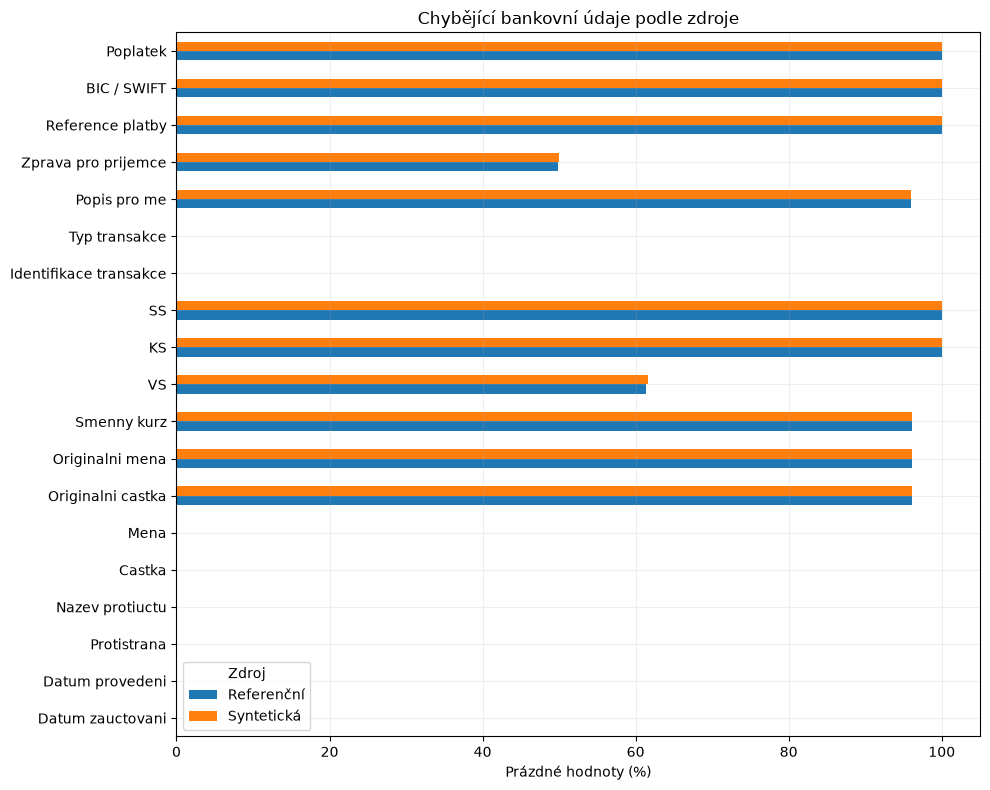

In [3]:
quality = pd.DataFrame({
    'Neplatné datum zaúčtování': df['Datum'].isna(),
    'Neplatné datum provedení': df['Provedeni'].isna(),
    'Neplatná částka': df['Castka_num'].isna(),
    'Prázdná měna': df['Mena'].eq(''),
    'Prázdný identifikátor': df[ID].eq(''),
    'Poškozený znak U+FFFD': df[raw.columns].apply(lambda col: col.str.contains('\ufffd', regex=False)).any(axis=1),
    'Zaúčtování před provedením': df['Datum'].lt(df['Provedeni']),
})
display(quality.groupby(df['Zdroj']).sum().T)
print('Zcela duplicitní bankovní řádky:', int(raw.duplicated().sum()))
missing = df[raw.columns].apply(lambda col: col.str.strip().eq('')).assign(Zdroj=df['Zdroj']).groupby('Zdroj').mean().T.mul(100)
display(missing.rename_axis('Sloupec').round(2))
missing.plot.barh(figsize=(10, 8), xlabel='Prázdné hodnoty (%)', title='Chybějící bankovní údaje podle zdroje')
plt.tight_layout(); plt.show()
assert not quality[['Neplatné datum zaúčtování', 'Neplatné datum provedení', 'Neplatná částka', 'Prázdná měna', 'Prázdný identifikátor', 'Poškozený znak U+FFFD']].any().any()

In [4]:
duplicates = df[df.duplicated(ID, keep=False)]
display(duplicates.groupby(['Zdroj', 'Kategorie', 'Mena']).agg(Radky=(ID, 'size'), Identifikatory=(ID, 'nunique')))
fx = df['Kategorie'].eq('směna měn')
print(f'Měnové směny: {fx.sum()} řádků, {df.loc[fx, ID].nunique()} identifikátorů.')
display(pd.crosstab(df['Zdroj'], df['Mena']))
display(pd.crosstab(df['Zdroj'], df['Originalni mena'].replace('', 'Neuvedena')))
# Duplicitní ID smějí reprezentovat pouze doložené dvě měnové nohy.
for identity, group in duplicates.groupby(ID):
    assert (len(group) == 2 and group['Kategorie'].eq('směna měn').all()
            and group['Zdroj'].nunique() == 1 and set(group['Mena']) == {'CZK', 'EUR'}
            and group['Castka_num'].prod() < 0
            and group['Typ transakce'].str.lower().str.contains('vyrovnávací', regex=False).all()), f'Nejasná duplicita: {identity}'
assert not raw.duplicated().any(), 'Zcela duplicitní bankovní řádky.'
assert np.isfinite(df['Castka_num']).all(), 'Nekonečná částka.'


,,,Radky,Identifikatory
Zdroj,Kategorie,Mena,,


Měnové směny: 0 řádků, 0 identifikátorů.


Mena,CZK
Zdroj,
Referenční,1625
Syntetická,9000


Originalni mena,EUR,Neuvedena
Zdroj,,
Referenční,63,1562
Syntetická,350,8650


## 3. Příjmy, výdaje a velikost plateb

Částky různých měn nesčítáme. Následující peněžní analýza používá zaúčtované **CZK a vylučuje měnové směny**. Částky jsou nominální, bez korekce inflace. Rozdíl příjmů a výdajů je čistý tok zahrnutých transakcí, nikoli zůstatek účtu; osobní převody nejsou automaticky spotřeba.

,Radky,Prijmy_CZK,Vydaje_CZK,Cisty_tok_CZK
Zdroj,,,,
Referenční,1625,"6,313,869.37","3,888,877.59","2,424,991.78"
Syntetická,9000,"35,517,217.71","20,066,669.69","15,450,548.02"


,count,mean,std,min,25%,50%,75%,90%,99%,max
Zdroj,,,,,,,,,,
Referenční,"1,487.00","2,615.25","5,198.24",15.04,390.88,771.20,"1,963.08","7,085.00","28,215.00","33,728.00"
Syntetická,"8,138.00","2,465.80","4,714.47",16.07,361.91,773.76,"1,887.62","6,792.50","25,296.00","33,728.00"


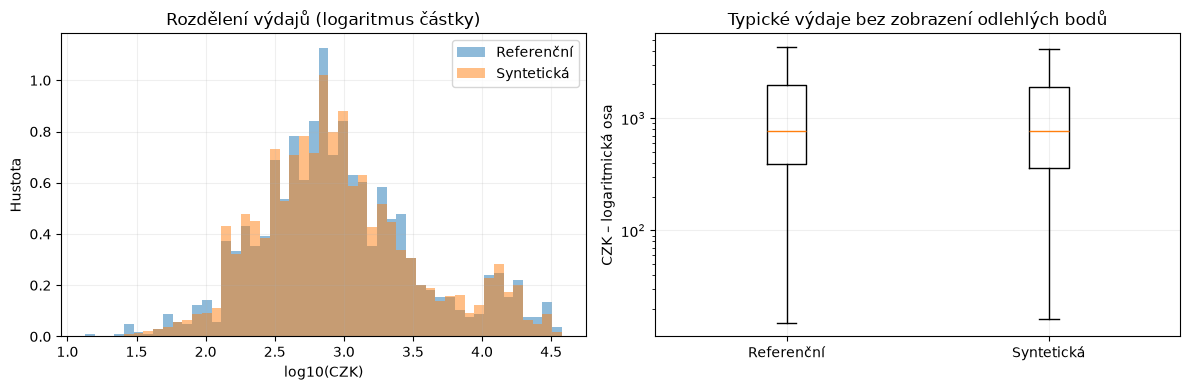

In [5]:
money = df.loc[df['Mena'].eq('CZK') & ~fx].copy()
money['Prijem'] = money['Castka_num'].clip(lower=0)
money['Vydaj'] = -money['Castka_num'].clip(upper=0)
expenses = money.loc[money['Vydaj'].gt(0)].copy()
flows = money.groupby('Zdroj').agg(Radky=(ID, 'size'), Prijmy_CZK=('Prijem', 'sum'), Vydaje_CZK=('Vydaj', 'sum'))
flows['Cisty_tok_CZK'] = flows['Prijmy_CZK'] - flows['Vydaje_CZK']
display(flows)
display(expenses.groupby('Zdroj')['Vydaj'].describe(percentiles=[.25, .5, .75, .9, .99]))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
log_amounts = np.log10(expenses['Vydaj'])
log_bins = np.linspace(log_amounts.min() - .05, log_amounts.max() + .05, 50)
for source, group in expenses.groupby('Zdroj'):
    axes[0].hist(np.log10(group['Vydaj']), bins=log_bins, alpha=.5, density=True, label=source)
axes[0].set(title='Rozdělení výdajů (logaritmus částky)', xlabel='log10(CZK)', ylabel='Hustota'); axes[0].legend()
groups = list(expenses.groupby('Zdroj'))
axes[1].boxplot([g['Vydaj'].to_numpy() for _, g in groups], tick_labels=[s for s, _ in groups], showfliers=False)
axes[1].set(yscale='log', title='Typické výdaje bez zobrazení odlehlých bodů', ylabel='CZK – logaritmická osa')
plt.tight_layout(); plt.show()

## 4. Vývoj v čase

Zdrojové soubory mohou pokrývat jen část roku nebo měsíce. Rok 2026 je neúplný; meziroční součty proto nelze přímo interpretovat jako růst spotřeby. Sady mají různý počet záznamů; součty nejsou přímým srovnáním chování osob. Obě sady zahrnují více smyšlených profilů.

První a poslední zaznamenaná platba ani počet aktivních dnů **nedokazují úplnost výpisu**. Měsíc bez záznamů může znamenat nulovou aktivitu i chybějící data; v grafu ponecháváme mezeru. Počet transakcí níže zahrnuje jen CZK bez směn.

Prvni   Posledni  Radky  Aktivni_dny
Zdroj      Rok                                           
Referenční 2022 2022-01-05 2022-12-22    358          187
           2023 2023-01-02 2023-12-29    333          189
           2024 2024-01-03 2024-12-30    350          197
           2025 2025-01-04 2025-12-31    314          179
           2026 2026-01-02 2026-10-05    270          153
Syntetická 2022 2022-01-02 2022-12-31   1889          344
           2023 2023-01-01 2023-12-31   1914          347
           2024 2024-01-02 2024-12-31   1853          350
           2025 2025-01-01 2025-12-30   1863          351
           2026 2026-01-01 2026-10-05   1481          261

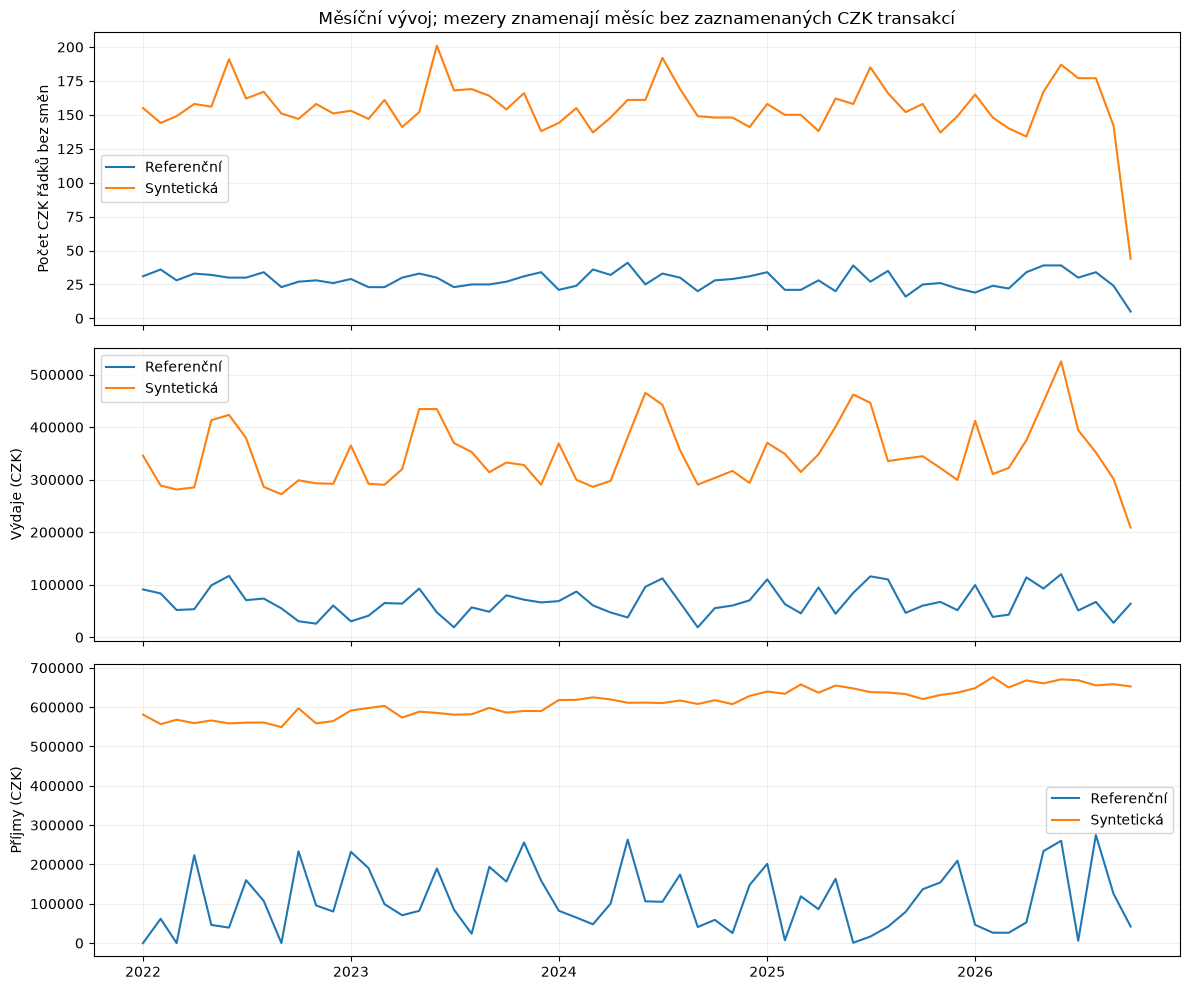

In [6]:
coverage = df.groupby(['Zdroj', df['Datum'].dt.year.rename('Rok')]).agg(
    Prvni=('Datum', 'min'), Posledni=('Datum', 'max'), Radky=(ID, 'size'), Aktivni_dny=('Datum', 'nunique'))
display(coverage)
money['Mesic'] = money['Datum'].dt.to_period('M').dt.to_timestamp()
monthly = money.groupby(['Zdroj', 'Mesic']).agg(Transakce=(ID, 'size'), Prijmy=('Prijem', 'sum'), Vydaje=('Vydaj', 'sum'))
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for source, group in monthly.groupby(level='Zdroj'):
    g = group.droplevel('Zdroj').asfreq('MS')
    for ax, column, title in zip(axes, ['Transakce', 'Vydaje', 'Prijmy'], ['Počet CZK řádků bez směn', 'Výdaje (CZK)', 'Příjmy (CZK)']):
        ax.plot(g.index, g[column], label=source); ax.set_ylabel(title); ax.legend()
axes[0].set_title('Měsíční vývoj; mezery znamenají měsíc bez zaznamenaných CZK transakcí')
plt.tight_layout(); plt.show()

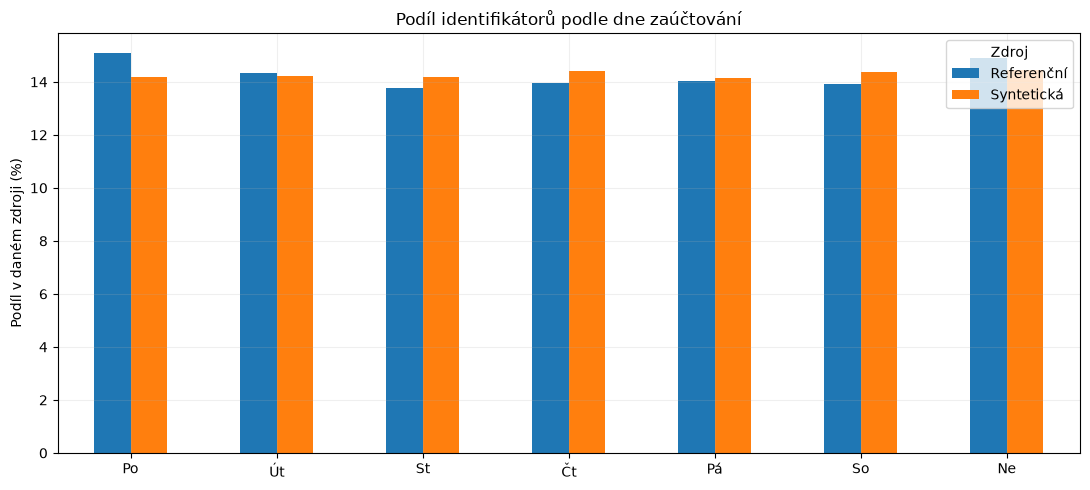

Prodleva zaúčtování (kalendářní dny):


,count,mean,std,min,25%,50%,75%,max
Zdroj,,,,,,,,
Referenční,"1,625.00",0.81,1.04,0.00,0.00,0.00,1.00,3.00
Syntetická,"9,000.00",0.80,1.03,0.00,0.00,0.00,1.00,3.00


In [7]:
weekday_names = ['Po', 'Út', 'St', 'Čt', 'Pá', 'So', 'Ne']
calendar_events = df.drop_duplicates(ID)
weekday = pd.crosstab(calendar_events['Datum'].dt.dayofweek, calendar_events['Zdroj'], normalize='columns').reindex(range(7), fill_value=0).mul(100)
weekday.index = weekday_names
weekday.plot.bar(title='Podíl identifikátorů podle dne zaúčtování', ylabel='Podíl v daném zdroji (%)', rot=0)
plt.tight_layout(); plt.show()
lag = (calendar_events['Datum'] - calendar_events['Provedeni']).dt.days
print('Prodleva zaúčtování (kalendářní dny):')
display(lag.groupby(calendar_events['Zdroj']).describe())

## 5. Kategorie: četnost, peněžní objem a rozdíly zdrojů

Četnosti počítáme také na unikátních identifikátorech, aby dvě nohy směny nezvyšovaly počet událostí. Peněžní objem zahrnuje pouze záporné CZK transakce bez směn a může obsahovat převody i splátky. Není to čistý spotřební koš.

Zdroj,Referenční,Syntetická,Referenční (%),Syntetická (%)
Kategorie,,,,
neurčeno,786,0,48.37,0.00
pojištění,145,684,8.92,7.60
energie,135,684,8.31,7.60
potraviny,123,704,7.57,7.82
restaurace,71,274,4.37,3.04
mzda,69,464,4.25,5.16
kultura a volný čas,30,0,1.85,0.00
dům a zahrada,28,0,1.72,0.00
osobní převod,24,168,1.48,1.87


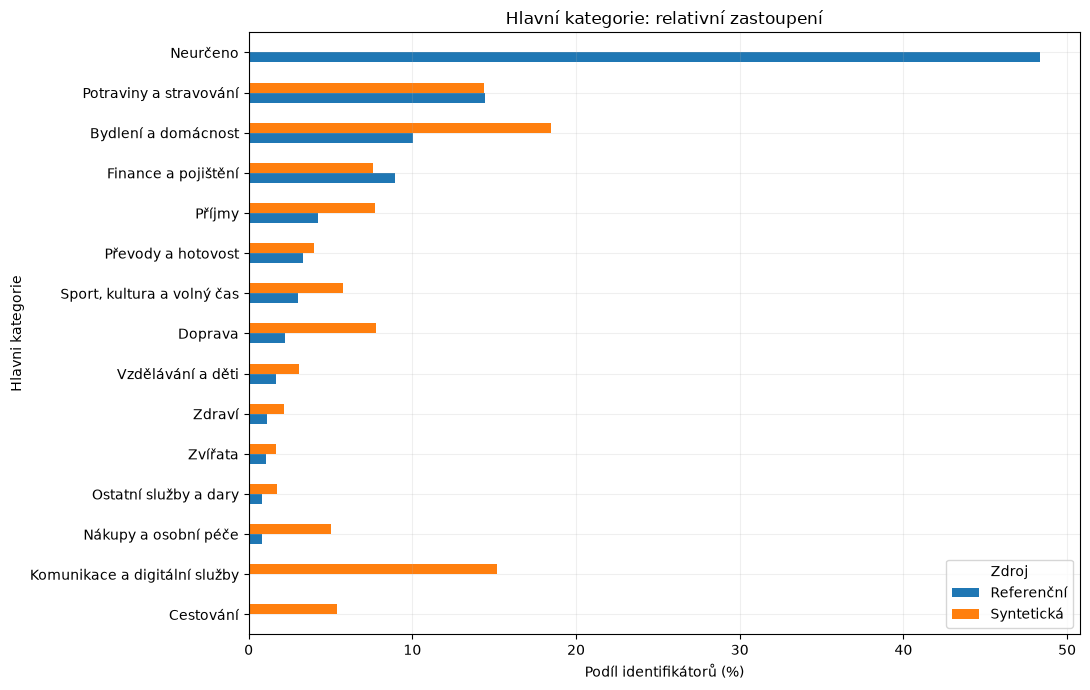

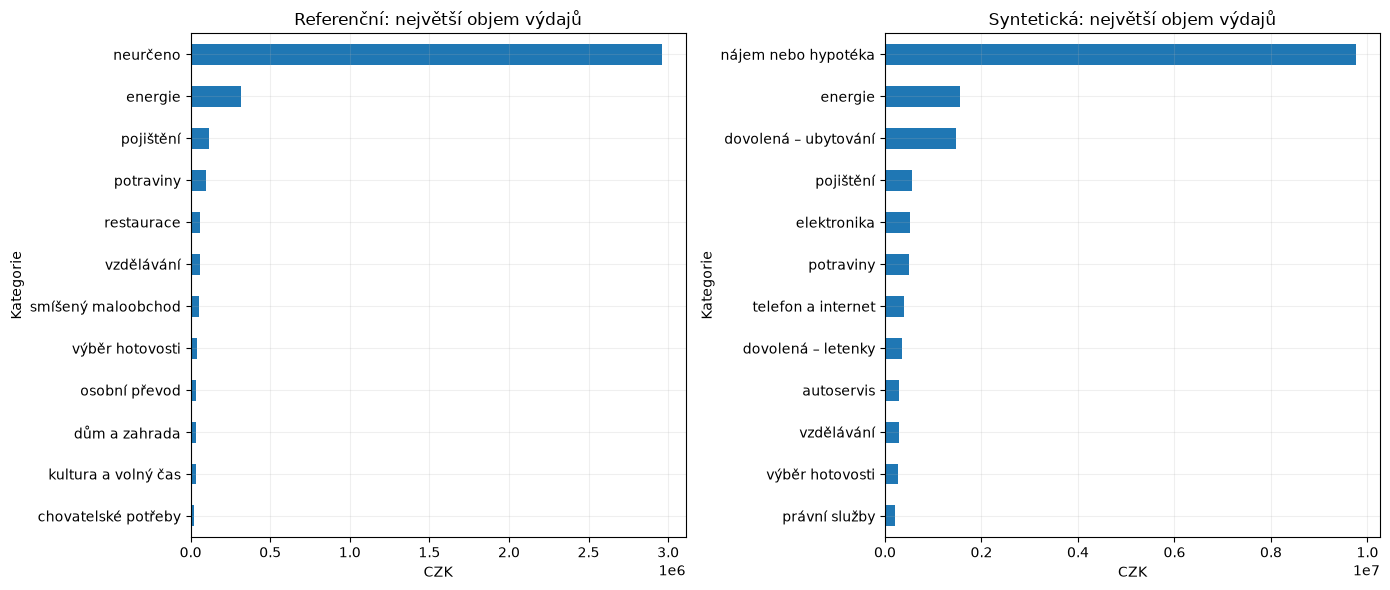

,Rozdíl syntetická − referenční (procentní body)
Kategorie,
neurčeno,-48.37
nájem nebo hypotéka,7.73
předplatné,7.60
telefon a internet,7.60
kultura a volný čas,-1.85
dům a zahrada,-1.72
veřejná doprava,1.48
pohonné hmoty,1.44
drogerie,1.33


In [8]:
events = df.drop_duplicates(ID).copy()
category_counts = pd.crosstab(events['Kategorie'], events['Zdroj'])
category_shares = category_counts.div(category_counts.sum(), axis=1).mul(100)
category_summary = category_counts.join(category_shares.add_suffix(' (%)'))
display(category_summary.sort_values('Referenční', ascending=False).head(20))
main_shares = pd.crosstab(events['Hlavni kategorie'], events['Zdroj'], normalize='columns').mul(100)
main_shares.sort_values('Referenční').plot.barh(figsize=(11, 7), xlabel='Podíl identifikátorů (%)', title='Hlavní kategorie: relativní zastoupení')
plt.tight_layout(); plt.show()
category_volume = expenses.groupby(['Kategorie', 'Zdroj'])['Vydaj'].sum().unstack(fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, source in zip(axes, ['Referenční', 'Syntetická']):
    category_volume[source].nlargest(12).sort_values().plot.barh(ax=ax)
    ax.set(title=f'{source}: největší objem výdajů', xlabel='CZK')
plt.tight_layout(); plt.show()
difference = category_shares['Syntetická'] - category_shares['Referenční']
display(difference.to_frame('Rozdíl syntetická − referenční (procentní body)').loc[difference.abs().nlargest(15).index])

In [9]:
# Kontrola názvů, hlavních skupin a četností řádků i identifikátorů.
labels = ['Kategorie', 'Kod hlavni kategorie', 'Hlavni kategorie']
lookup = dictionary.set_index('Kod kategorie')
for column in labels:
    assert df[column].eq(df['Kod kategorie'].map(lookup[column])).all(), f'Neaktuální mapování: {column}'
for source, row_column, event_column in [
    ('Referenční', 'Cetnost originalni radky', 'Cetnost originalni identifikatory'),
    ('Syntetická', 'Cetnost synteticke radky', 'Cetnost synteticke identifikatory')]:
    for frame, column in [(df, row_column), (events, event_column)]:
        actual = frame.loc[frame['Zdroj'].eq(source), 'Kod kategorie'].value_counts()
        saved = lookup[column].astype(int)
        assert actual.reindex(saved.index, fill_value=0).equals(saved.rename(actual.name)), f'Neaktuální číselník: {column}'
actual = df['Kod kategorie'].value_counts().reindex(lookup.index, fill_value=0)
assert actual.equals(lookup['Cetnost spolecne radky'].astype(int).rename(actual.name))
print('Mapování a četnosti řádků i identifikátorů odpovídají datům.')


Mapování a četnosti řádků i identifikátorů odpovídají datům.


## 6. Protistrany, typy operací a syntetické profily

Přesný název protistrany může mít různé bankovní varianty. Tento přehled je neslučuje do firemních entit. Osobní jména ani čísla účtů nevypisujeme v přehledu největších plateb; notebook lze přesto považovat za odvozený datový artefakt.

Zdroj,Referenční,Syntetická
Typ transakce,,
Nákup u obchodníka,43.82,42.78
Trvalý příkaz,31.08,30.53
Příchozí úhrada,7.51,8.69
Opakovaná platba,6.34,7.60
Nákup na internetu,5.85,5.30
Odchozí úhrada,3.57,2.96
Vrácení nákupu,0.98,0.89
Výběr hotovosti z bankomatu,0.86,1.26


,Různé neprázdné názvy,Podíl 10 nejčastějších mezi neprázdnými (%)
Zdroj,,
Referenční,103,45.42
Syntetická,106,47.01


,,Transakce,Prijmy_CZK,Vydaje_CZK,Kategorie
Profil,Typ profilu,,,,
S01,studentka,665,"925,074.48","769,572.81",62
S02,mladý zaměstnanec,681,"2,176,600.52","1,414,838.58",63
S03,rodina s dětmi,831,"3,604,515.94","2,098,677.82",62
S04,důchodce,606,"1,384,942.39","718,900.17",59
S05,podnikatelka,799,"4,908,556.04","2,516,954.71",63
S06,častý cestovatel,893,"3,953,077.79","2,334,716.99",64
S07,rodič na rodičovské,666,"1,486,934.53","996,158.71",59
S08,motorista,735,"2,928,950.38","1,533,776.80",59
S09,kultura a gastronomie,780,"2,629,297.66","1,591,828.80",60


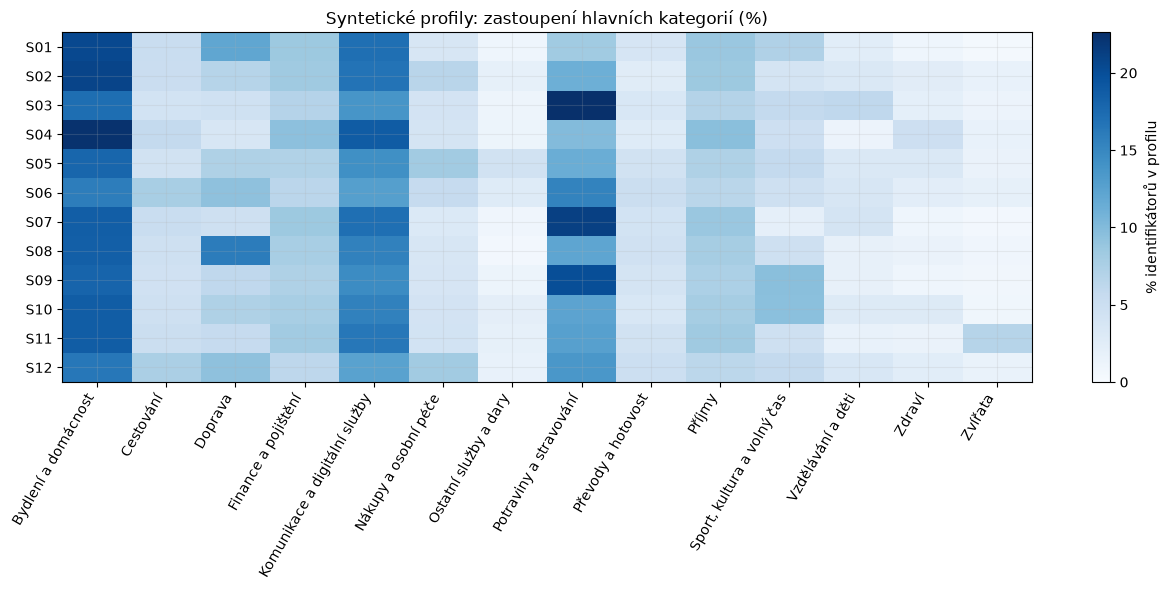

In [10]:
operation_shares = pd.crosstab(df['Typ transakce'], df['Zdroj'], normalize='columns').mul(100)
display(operation_shares.sort_values('Referenční', ascending=False))
merchant_summary = []
for source, group in money.groupby('Zdroj'):
    counts = group.loc[group['Nazev protiuctu'].ne(''), 'Nazev protiuctu'].value_counts()
    merchant_summary.append({'Zdroj': source, 'Různé neprázdné názvy': len(counts),
                             'Podíl 10 nejčastějších mezi neprázdnými (%)': 100 * counts.head(10).sum() / counts.sum() if counts.sum() else np.nan})
display(pd.DataFrame(merchant_summary).set_index('Zdroj'))
profile_summary = money.loc[money['Zdroj'].eq('Syntetická')].groupby(['Profil', 'Typ profilu']).agg(
    Transakce=(ID, 'size'), Prijmy_CZK=('Prijem', 'sum'), Vydaje_CZK=('Vydaj', 'sum'), Kategorie=('Kategorie', 'nunique'))
display(profile_summary)
profile_mix = pd.crosstab(events.loc[events['Zdroj'].eq('Syntetická'), 'Profil'],
                          events.loc[events['Zdroj'].eq('Syntetická'), 'Hlavni kategorie'], normalize='index').mul(100)
fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(profile_mix, aspect='auto', cmap='Blues', vmin=0)
ax.set_xticks(range(len(profile_mix.columns)), profile_mix.columns, rotation=60, ha='right')
ax.set_yticks(range(len(profile_mix.index)), profile_mix.index)
ax.set_title('Syntetické profily: zastoupení hlavních kategorií (%)')
fig.colorbar(im, ax=ax, label='% identifikátorů v profilu')
plt.tight_layout(); plt.show()

## 7. Odlehlé částky a informace dostupné pro LLM

Vysoká částka nemusí být chyba: může jít o převod, splátku nebo investici. Ukazujeme horní percentily a omezený přehled největších výdajů. Poznámky syntetických plateb mohou přímo prozradit scénář generátoru; při experimentu je vhodné vyhodnotit variantu s poznámkami i bez nich.

In [11]:
for source, group in expenses.groupby('Zdroj'):
    print(f'{source}: 6 největších výdajů v CZK bez směn')
    display(group.nlargest(6, 'Vydaj')[['Datum', 'Vydaj', 'Kategorie', 'Typ transakce']])
information = pd.DataFrame({
    'Název protiúčtu': df['Nazev protiuctu'].ne(''),
    'Popis pro mě': df['Popis pro me'].ne(''),
    'Zpráva pro příjemce': df['Zprava pro prijemce'].ne(''),
    'Alespoň jedna poznámka': df['Popis pro me'].ne('') | df['Zprava pro prijemce'].ne(''),
}).groupby(df['Zdroj']).mean().mul(100)
display(information.rename_axis('Zdroj').round(2))
assert audit[ID].is_unique
reference_events = events.loc[events['Zdroj'].eq('Referenční')].merge(
    audit[[ID, 'Jistota', 'Kategorie']].rename(columns={'Kategorie': 'Audit_kategorie'}), on=ID, how='left', validate='one_to_one')
assert reference_events['Jistota'].notna().all()
assert set(audit[ID]) == set(reference_events[ID]), 'Neaktuální rozsah auditu.'
assert reference_events['Audit_kategorie'].eq(reference_events['Puvodni kategorie']).all(), 'Audit má jiné kategorie než metadata.'
display(pd.crosstab(reference_events['Jistota'], reference_events['Hlavni kategorie']))
print('Jistota pravidel je orientační označení, nikoli kalibrovaná pravděpodobnost.')

Referenční: 6 největších výdajů v CZK bez směn


,Datum,Vydaj,Kategorie,Typ transakce
4535,2024-01-06,"33,728.00",neurčeno,Nákup na internetu
5628,2024-07-07,"33,728.00",neurčeno,Nákup na internetu
6744,2025-01-07,"33,728.00",neurčeno,Nákup na internetu
8904,2026-01-05,"33,728.00",neurčeno,Nákup na internetu
8905,2026-01-05,"31,860.00",neurčeno,Trvalý příkaz
9418,2026-04-05,"31,860.00",neurčeno,Trvalý příkaz


Syntetická: 6 největších výdajů v CZK bez směn


,Datum,Vydaj,Kategorie,Typ transakce
75,2022-01-10,"33,728.00",dovolená – ubytování,Nákup na internetu
1030,2022-06-13,"33,728.00",dovolená – ubytování,Nákup na internetu
2322,2023-01-09,"33,728.00",dovolená – ubytování,Nákup na internetu
3411,2023-07-06,"33,728.00",dovolená – ubytování,Nákup na internetu
4562,2024-01-11,"33,728.00",dovolená – ubytování,Nákup na internetu
5694,2024-07-15,"33,728.00",dovolená – ubytování,Nákup na internetu


,Název protiúčtu,Popis pro mě,Zpráva pro příjemce,Alespoň jedna poznámka
Zdroj,,,,
Referenční,100.00,4.06,50.15,52.43
Syntetická,100.00,4.00,50.00,52.20


Hlavni kategorie,Bydlení a domácnost,Doprava,Finance a pojištění,Neurčeno,Nákupy a osobní péče,Ostatní služby a dary,Potraviny a stravování,Převody a hotovost,Příjmy,"Sport, kultura a volný čas",Vzdělávání a děti,Zdraví,Zvířata
Jistota,,,,,,,,,,,,,
nízká,0,0,0,786,0,0,0,0,0,0,0,0,0
střední,28,0,0,0,9,13,90,24,0,30,14,18,17
vysoká,135,36,145,0,4,0,145,30,69,19,13,0,0


Jistota pravidel je orientační označení, nikoli kalibrovaná pravděpodobnost.


## 8. Zjištění a doporučení pro experiment

Následující souhrn se přepočítává z dat. Shodu LLM s heuristikou lze měřit nad celým výpisem, správnost ale vyžaduje samostatný ručně ověřený vzorek. Při jeho tvorbě zahrňte vzácné kategorie, chybějící poznámky, neznámé protistrany a smíšené obchody. Ukázky pro prompt oddělte od závěrečného testu; sledujte i obchodníky bez ukázky v promptu.

In [12]:
unknown = events['Kategorie'].eq('neurčeno').groupby(events['Zdroj']).mean().mul(100)
lines = [f'- Celkem **{len(df):,} bankovních řádků** a **{len(events):,} identifikátorů**.',
         f'- Měnové směny tvoří **{fx.sum()} řádků**; z peněžních souhrnů jsou vynechány.']
for source in ['Referenční', 'Syntetická']:
    group = events.loc[events['Zdroj'].eq(source)]
    top = category_counts[source].idxmax()
    lines.append(f'- **{source}**: {len(group):,} identifikátorů, {group["Kategorie"].nunique()} kategorií; '
                 f'nejčastější „{top}“ ({category_shares.loc[top, source]:.1f} %), neurčeno {unknown.get(source, 0):.1f} %.')
lines.extend(['- Hlavní syntetická sada je početnější než referenční; společná metrika by byla ovládána hlavní sadou. Obě pocházejí ze stejného typu generátoru.',
              '- Oba zdroje jsou plně syntetické a pocházejí z více smyšlených profilů; nepopisují skutečného majitele účtu.',
              '- Z výpisu bez položek nákupu nelze spolehlivě odvodit detailní účel všech plateb. Model musí mít možnost odpovědět „neurčeno“.',
              '- Pro LLM neposílat současnou kategorii, auditní důvod ani profilové scénáře. Reportovat macro-F1, podíl neurčeno a rychlost zvlášť podle zdroje.'])
display(Markdown('\n'.join(lines)))

- Celkem **10,625 bankovních řádků** a **10,625 identifikátorů**.
- Měnové směny tvoří **0 řádků**; z peněžních souhrnů jsou vynechány.
- **Referenční**: 1,625 identifikátorů, 24 kategorií; nejčastější „neurčeno“ (48.4 %), neurčeno 48.4 %.
- **Syntetická**: 9,000 identifikátorů, 68 kategorií; nejčastější „potraviny“ (7.8 %), neurčeno 0.0 %.
- Hlavní syntetická sada je početnější než referenční; společná metrika by byla ovládána hlavní sadou. Obě pocházejí ze stejného typu generátoru.
- Oba zdroje jsou plně syntetické a pocházejí z více smyšlených profilů; nepopisují skutečného majitele účtu.
- Z výpisu bez položek nákupu nelze spolehlivě odvodit detailní účel všech plateb. Model musí mít možnost odpovědět „neurčeno“.
- Pro LLM neposílat současnou kategorii, auditní důvod ani profilové scénáře. Reportovat macro-F1, podíl neurčeno a rychlost zvlášť podle zdroje.